# Imports

In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Macros

In [2]:
DEVICE = 'cuda'
DATASET_PATH = 'dataset/original/dataset.pt'
BATCH_SIZE = 1

# Dataset

In [3]:
class ModSeekDataset(Dataset):
    def __init__(self, qs: pd.DataFrame, sols = pd.DataFrame):
        self.qs_cols = qs.columns
        self.sols_cols = sols.columns
        
        self.num_qs = len(self.qs_cols)
        self.num_sols = len(self.sols_cols)
        
        self.qs_inst_tensor = torch.tensor(qs.to_numpy())
        self.sols_inst_tesor = torch.tensor(sols.to_numpy())
        
    def __getitem__(self, index):
        return self.qs_inst_tensor[index], self.sols_inst_tesor[index]
    
    def __len__(self):
        return len(self.qs_inst_tensor)

In [4]:
dataset: ModSeekDataset = torch.load(DATASET_PATH)
DATASET_SIZE = len(dataset)
TRAIN_RATIO = 0.7
TEST_RATIO = 1 - TRAIN_RATIO

train_len = int(DATASET_SIZE * TRAIN_RATIO)
test_len = DATASET_SIZE - train_len

torch.manual_seed(196)
train_dataset, test_dataset = random_split(dataset, (train_len, test_len))
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(len(train_loader))
print(len(test_loader))

700
300


C:\Users\agile\AppData\Local\Temp\ipykernel_34268\3191046002.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset: ModSeekDataset = torch.load(DATASET_PATH)


# Model

This model was inspired by the bayes theorem
<bayes theorem equation>

<explain intuition>

In [ ]:
class ModSeek(torch.nn.Module):
    def __init__(self, num_qs: int, num_sols: int):
        super().__init__()
        
        self.num_qs = num_qs
        self.num_sols = num_sols
        self.W_yes = torch.nn.Parameter(torch.randn(1, num_qs, num_sols))
        self.W_no = torch.nn.Parameter(torch.randn(1, num_qs, num_sols))
        self.bias = torch.nn.Parameter(torch.randn(self.num_sols))
    
    def forward(self, answered_qs):        
        answered_qs_dimmed = answered_qs.unsqueeze(-1)
        
        # (B, nq, ns) = (B, nq, 1) * (1, nq, ns) + (B, nq, 1) * (1, nq, ns)
        z_iter = answered_qs_dimmed * self.W_yes + (1 - answered_qs_dimmed) * self.W_no
        z = self.bias + z_iter.sum(dim=1)
        return z

In [6]:
mod_seek = ModSeek(dataset.num_qs, dataset.num_sols)
optimizer = torch.optim.Adam(mod_seek.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
num_epochs = 15

In [7]:
mod_seek.train()
loss_ot = []

for epoch in range(num_epochs):
    total_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch}", leave=True)
    
    for answered_qs, sols in loop:
        optimizer.zero_grad()
        probs = torch.sigmoid(mod_seek(answered_qs))
        loss = criterion(probs, sols)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # update bar with live loss
        loop.set_postfix(loss=loss.item())
    
    mean_loss = total_loss / len(train_loader)
    loss_ot.append(mean_loss)
    
    print(f"Epoch {epoch}: loss = {mean_loss}")

Epoch 0: 100%|██████████| 700/700 [00:07<00:00, 95.89it/s, loss=0.196]  


Epoch 0: loss = 0.22838309022997108


Epoch 1: 100%|██████████| 700/700 [00:06<00:00, 104.48it/s, loss=0.0166]


Epoch 1: loss = 0.11309560405622636


Epoch 2: 100%|██████████| 700/700 [00:06<00:00, 105.91it/s, loss=0.167]  


...

Epoch 12: loss = 0.00015468307536918604


Epoch 13: 100%|██████████| 700/700 [00:01<00:00, 354.30it/s, loss=0.000133]


Epoch 13: loss = 0.00010736829134527528


Epoch 14: 100%|██████████| 700/700 [00:01<00:00, 360.65it/s, loss=4.66e-5] 

Epoch 14: loss = 7.501045242471653e-05


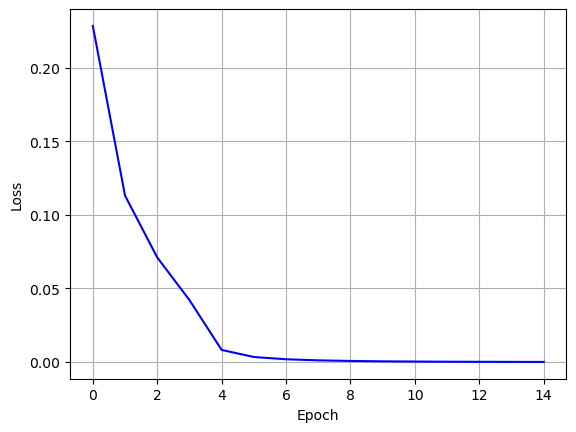

In [8]:
x = list(range(num_epochs))
plt.plot(x, loss_ot, color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig(
    'loss-overtime.png',
    dpi=600,
    bbox_inches='tight',
    pad_inches=0,
    format='png'
)
plt.show()

# Saving & Loading Model

Save

In [9]:
torch.save(mod_seek, 'mod_seek.pt')

Load

In [10]:
mod_seek = ModSeek(dataset.num_qs, dataset.num_sols)
mod_seek = torch.load('mod_seek.pt')
mod_seek.eval()

C:\Users\agile\AppData\Local\Temp\ipykernel_34268\2495465887.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mod_seek = torch.load('mod_seek.pt')


ModSeek()

In [13]:
torch.save(mod_seek.state_dict(), 'mod_seek_weights.pt')

# Testing

In [12]:
TP = 0
FP = 0
FN = 0
TN = 0

with torch.no_grad():
    for answered_qs, sols in test_loader:
        batched_probs = torch.sigmoid(mod_seek(answered_qs))
        
        for batch_idx, probs in enumerate(batched_probs):
            for i, prob in enumerate(probs):
                
                if prob >= 0.5 and sols[batch_idx][i] == 1:
                    TP += 1
                    
                elif prob >= 0.5 and sols[batch_idx][i] != 1:
                    FP += 1
                    
                elif prob < 0.5 and sols[batch_idx][i] == 1:
                    FN += 1
                    
                elif prob < 0.5 and sols[batch_idx][i] != 1:
                    TN += 1

precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f'Precision: {precision}')
print(f'Recall: {recall}')

Precision: 1.0
Recall: 1.0
